In [2]:
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D

In [14]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 2

# 1) Ler convertendo "Null" para NaN
df_all_2d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_2d.columns:
        df_all_2d[c] = pd.to_numeric(df_all_2d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_2d = df_all_2d.dropna(subset=["pt_mean","nt_mean"]).copy()

# ver somente um range de colunas
df_clean_2d.loc[:, "rho":"nt_erro"]

,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro
0,0.003,0.4,1,22,5,0.908370,0.002816,194.361265,1.179564
3,0.003,0.5,1,20,20,0.916450,0.002608,191.887922,2.029277
4,0.003,0.5,2,20,12,0.915509,0.001478,192.424168,2.841733
5,0.003,0.5,3,20,6,0.918368,0.002620,199.855251,0.038917
6,0.003,0.7,1,100,100,0.923992,0.000430,199.306918,0.127607
...,...,...,...,...,...,...,...,...,...
108,0.120,0.5,1,20,1,0.999580,0.000000,106.448556,0.000000
111,0.120,0.7,1,100,8,0.999348,0.000301,99.039740,8.601468
114,0.120,0.8,1,20,2,0.999698,0.000269,90.956154,12.398664
117,0.120,1.0,1,100,14,0.999396,0.000090,97.995344,4.345035


In [2]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df_all_3d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_3d.columns:
        df_all_3d[c] = pd.to_numeric(df_all_3d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_3d = df_all_3d.dropna(subset=["pt_mean","nt_mean"]).copy()

# ver somente um range de colunas
df_clean_3d.loc[:, "rho":"nt_erro"]

,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro
0,0.00010,1.0,1,300,300,0.519685,0.000993,199.731757,0.279058
1,0.00010,1.0,2,300,300,0.520621,0.000865,199.581298,0.253774
2,0.00010,1.0,3,300,300,0.521422,0.000980,199.787627,0.129536
3,0.00010,1.0,4,300,299,0.521684,0.000274,199.838035,0.075023
4,0.00520,1.0,1,300,300,0.521888,0.000218,199.901805,0.065983
...,...,...,...,...,...,...,...,...,...
1152,0.22755,1.0,1,50,40,1.000000,0.000000,419.855711,25.980808
1153,0.22755,1.0,2,50,17,1.000000,0.000000,322.756419,27.112908
1154,0.22755,1.0,3,50,3,1.000000,0.000000,388.235370,145.779638
1155,0.22755,1.0,4,50,1,1.000000,0.000000,197.250521,0.000000


FileNotFoundError: [Errno 2] No such file or directory: '/home/junior/Documents/self_organization_percolation/Data/bond_percolation/num_colors_4/dim_3/L_1000/NT_constant/NT_12000/k_1.0e-06/rho_1.0000e-03/data/P0_0.10_p0_0.40_seed_995138328.json'

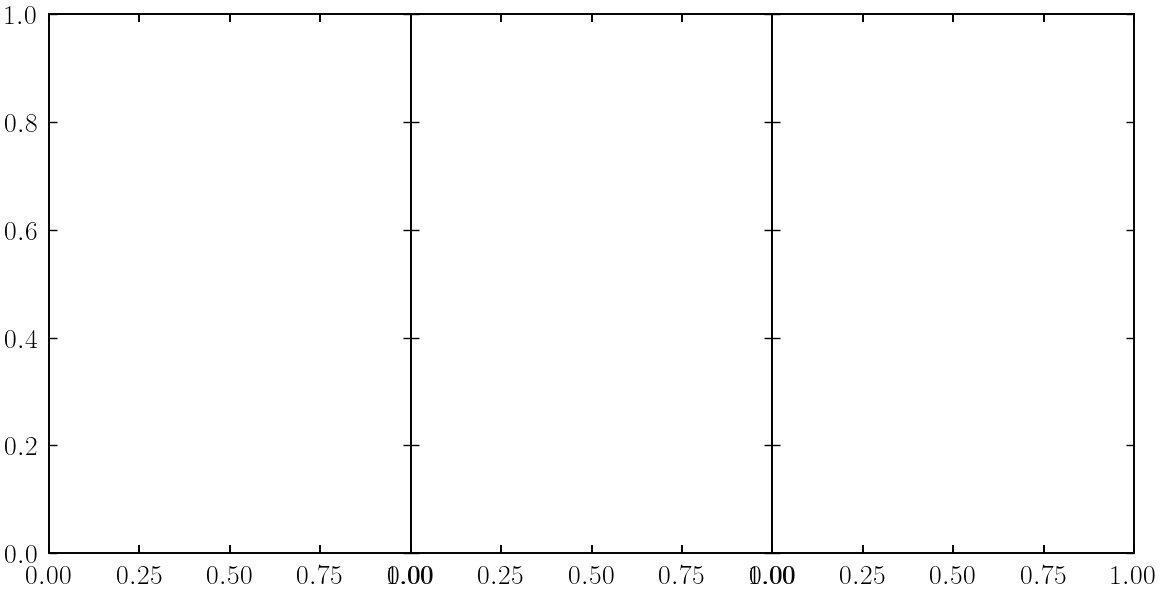

In [ ]:
# ---------- seus parâmetros ----------
type_perc = "bond"
num_colors = 4
dim = 3
L = 1024
NT = 12000
k=1.0e-07
rho=1.0e-03
p0_lst = [0.4, 0.8, 1.0]
seed_name = [995138328, 587086589, 572198292]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95

# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharex=True, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0, 'hspace': 0}  # cola os subplots
)

results = []
rng = np.random.default_rng(12345)

count = 0
linestyles = ['solid', 'dashed', 'dashdot', "dotted", 'None']
labels_sub = ["$(a)$", "$(b)$", "$(c)$"]
#linestyles = ['solid', 'solid', 'solid', 'solid']

for index, ax in enumerate(axes):
    p0 = p0_lst[index]
    data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed_name[index])
    
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"p_{i}"], ls=linestyles[i-1], label=f"$i = {i}$", linewidth=1.5*thickness)

    ax.set_xlabel("$t$")
    ax.xaxis.set_major_locator(MultipleLocator(500))
    ax.set_xlim([0, max(data["t"])])
    ax.set_ylim([0.3, 1.0])

    means_per_curve = []
    for i in range(1, num_colors+1):
        mi = tail_mean(data[f"p_{i}"], tail_frac=tail_frac)
        if np.isfinite(mi):
            means_per_curve.append(mi)

    mean_pt, se_pt, (lo_pt, hi_pt) = bootstrap_mean_scalar(means_per_curve,prop='pt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"p0": p0, "mean": mean_pt, "se": se_pt, "lo": lo_pt, "hi": hi_pt, "n_used": len(means_per_curve)})
    count += mean_pt
    ax.legend(fontsize=18)
    #ax.set_title(fr"$p_0={p0:.1f}$", fontsize=18)
    txt1 = fmt_pm(mean_pt, se_pt, len(means_per_curve), dec=4)   # usa "<1e-3" se for minúsculo
    txt2 = rf"$p_0 = {p0:.1f}$"
    txt3 = ""
    ax.text(0.06, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.06, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.90, 0.1, labels_sub[index], transform=ax.transAxes, ha="left", va="top", fontsize=25)

for ax in axes:
    ax.axhline(y=count/3, xmin=0, xmax=1.0, color='k', ls='--', lw=thickness)  # xmin/xmax em fração do eixo
    ax.set_xlim([0, 1000])
axes[0].set_ylabel(r"$p(t)$")
# tira rótulos de y dos painéis internos para ficar limpo/colado
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# margens externas (não afetam o espaçamento entre subplots)
fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $N_T = {NT}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)

plt.show()

# ---------- resumo no console ----------
print("Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):")
for r in results:
    print(f"p0={r['p0']:.1f} | n_curves={r['n_used']} | "
          f"mean={r['mean']:.6f} ± {r['se']:.6f} (IC{int(ci*100)}%: {r['lo']:.6f}–{r['hi']:.6f})")

FileNotFoundError: [Errno 2] No such file or directory: '/home/junior/Documents/self_organization_percolation/Data/bond_percolation/num_colors_4/dim_3/L_1024/NT_constant/NT_12000/k_1.0e-07/rho_1.0000e-03/data/P0_0.10_p0_0.40_seed_995138328.json'

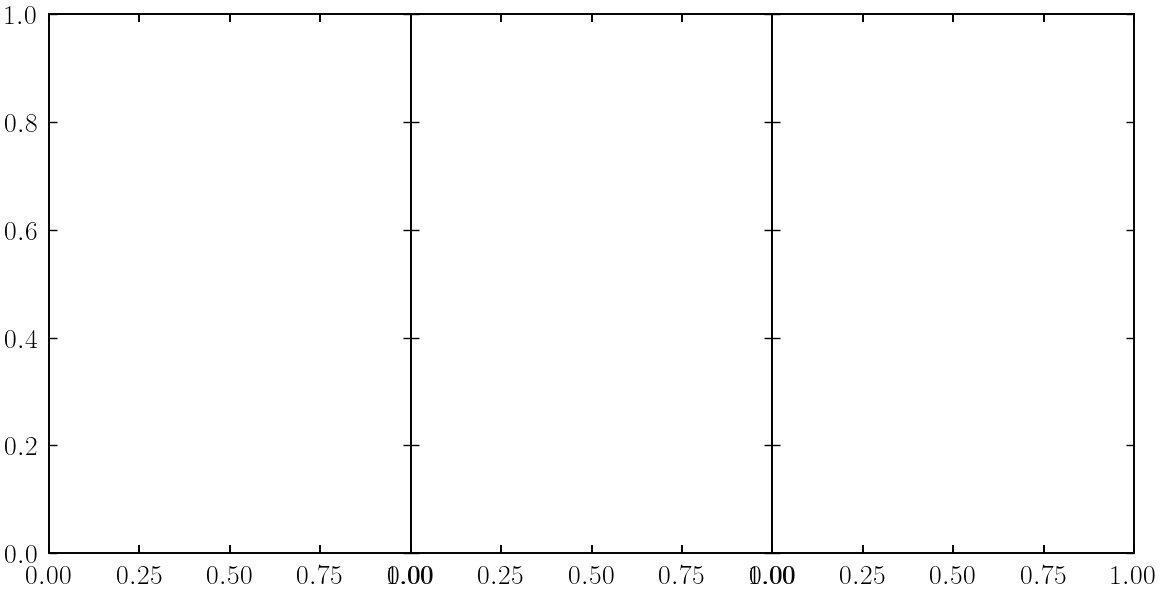

In [ ]:
# ---------- seus parâmetros ----------
type_perc = "bond"
num_colors = 4
dim = 3
L = 1024
NT = 12000
k=1.0e-07
rho=1.0e-03
p0_lst = [0.3, 0.7, 1.0]
seed_name = [995138328, 587086589, 2096499534]


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95
labels_sub = ["$(a)$", "$(b)$", "$(c)$"]

# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0.06, 'hspace': 0}  # pequeno respiro evita sobreposição do 0/400
)

results = []
rng = np.random.default_rng(54321)

count = 0
linestyles = ['solid', 'dashed', 'dashdot', "dotted", 'None']
#linestyles = ['solid', 'solid', 'solid', 'solid']
for index, ax in enumerate(axes):
    p0 = p0_lst[index]
    data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed_name[index])
    
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"N_{i}"], ls=linestyles[i-1], label=f"$i = {i}$", linewidth=1.5*thickness)

    ax.set_xlabel("$t$")
    ax.xaxis.set_major_locator(MultipleLocator(500))
    ax.set_xlim([0, max(data["t"])])
    #ax.set_ylim([0.4, 1.0])

    means_per_curve_Nt = []
    for i in range(1, num_colors+1):
        mi = tail_mean(data[f"N_{i}"], tail_frac=tail_frac)
        if np.isfinite(mi):
            means_per_curve_Nt.append(mi)

    mean_Nt, se_Nt, (lo_Nt, hi_Nt) = bootstrap_mean_scalar(means_per_curve_Nt, prop='Nt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"p0": p0, "mean": mean_Nt, "se": se_Nt, "lo": lo_Nt, "hi": hi_Nt, "n_used": len(means_per_curve_Nt)})
    count += mean_Nt
    ax.legend(fontsize=18)
    
    txt1 = fmt_pm_N(mean_Nt, se_Nt, n_used=len(means_per_curve_Nt), dec=0)  # ajuste dec se quiser
    txt2 = rf"$p_0 = {p0:.1f}$"
    ax.text(0.06, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.06, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.77, 0.70, labels_sub[index], transform=ax.transAxes, ha="left", va="top", fontsize=25)

for ax in axes:
    ax.axhline(y=count/3, xmin=0, xmax=1.0, color='k', ls='--', lw=thickness)  # xmin/xmax em fração do eixo
    ax.set_xlim([0, 2000])
    #ax.set_ylim([-300, 20000])
axes[0].set_ylabel(r"$N(t)$")
# tira rótulos de y dos painéis internos para ficar limpo/colado
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# margens externas (não afetam o espaçamento entre subplots)
fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $N_T = {NT}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)

plt.show()

# # ---------- resumo no console ----------
# print("Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):")
# for r in results:
#     print(f"p0={r['p0']:.1f} | n_curves={r['n_used']} | "
#           f"mean={r['mean']:.6f} ± {r['se']:.6f} (IC{int(ci*100)}%: {r['lo']:.6f}–{r['hi']:.6f})")

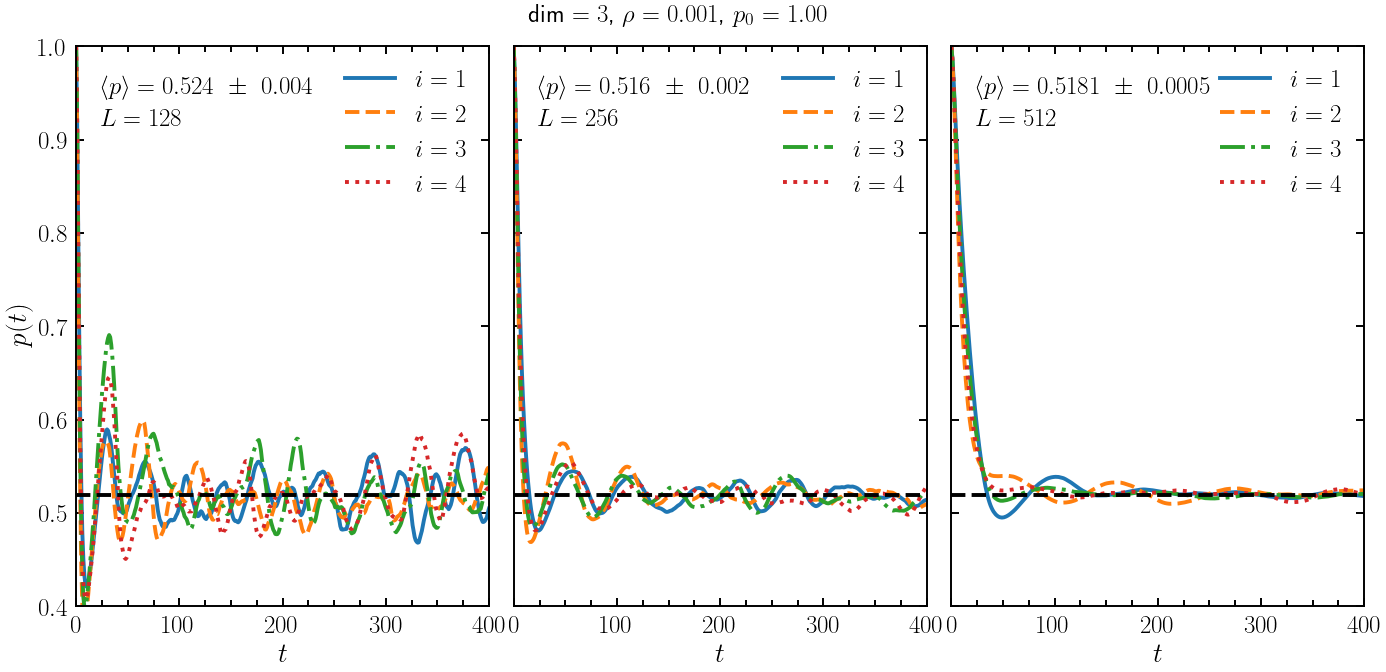

In [22]:
from matplotlib.ticker import MultipleLocator

# ---------- parâmetros (três tamanhos) ----------
type_perc = "bond"
num_colors = 4
dim = 3
L_list  = [128, 256, 512]
NT_list = [200, 800, 3500]
k_list  = [1.0e-04, 1.0e-05, 1.0e-06]
rho = 1.0e-03
p0  = 1.00
seed_list = [319660365, 830093962, 1211460012]

fontsize_ticks = 18
thickness = 1.4
tail_frac = 0.30
n_boot    = 20000
ci        = 0.95


# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0.06, 'hspace': 0}  # pequeno respiro evita sobreposição do 0/400
)

results = []
rng = np.random.default_rng(12345)
count = 0

# locators para ticks e subticks
major_step = 100   # 0, 100, 200, 300, 400
minor_step = 25    # subticks sem rótulo

for j, (ax, L, NT, kk, seed) in enumerate(zip(axes, L_list, NT_list, k_list, seed_list)):
    data = data_single_sample(type_perc, num_colors, dim, L, NT, kk, rho, p0, seed)

    # curvas p_i(t)
    linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"p_{i}"], ls=linestyles[i-1],
                label=f"$i = {i}$", linewidth=2*thickness)

    # ----- eixo x local (0–400) com subticks -----
    ax.set_xlim([0, 400])
    ax.set_ylim(0.4, 1.0)
    ax.set_xlabel("$t$")

    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))

    # aparência dos ticks
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)

    # (opcional, para reforçar que é eixo local) legenda curta do intervalo:
    # ax.text(0.98, -0.16, r"[0, 400]", transform=ax.transAxes,
    #         ha="right", va="top", fontsize=fontsize_ticks-2)

    # ===== resto do seu código inalterado =====
    means_per_curve = [tail_mean(data[f"p_{i}"], tail_frac=tail_frac)
                       for i in range(1, num_colors+1)]
    means_per_curve = [m for m in means_per_curve if np.isfinite(m)]

    mean_pt, se_pt, (lo_pt, hi_pt) = bootstrap_mean_scalar(
        means_per_curve, prop='pt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"L": L, "NT": NT, "k": kk, "mean": mean_pt, "se": se_pt,
                    "lo": lo_pt, "hi": hi_pt, "n_used": len(means_per_curve)})

    ax.legend(fontsize=18)
    txt1 = fmt_pm(mean_pt, se_pt, n_used=len(means_per_curve),
                  dec=(3 if count!=2 else 4))
    txt2 = rf"$L = {L}$"
    ax.text(0.06, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.06, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    count += 1

axes[0].set_ylabel(r"$p(t)$")
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# (opcional) remova as linhas verticais de "divisão" se estiver usando:
# for ax in axes: pass  # não desenhar axvline(400)

# linha média global
global_mean = np.nanmean([r["mean"] for r in results])
for ax in axes:
    ax.axhline(y=global_mean, xmin=0, xmax=1.0, color='k', ls='--', lw=2*thickness)

fig.suptitle(fr"dim $= {dim}$, $\rho={rho}$, $p_0={p0:.2f}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)
plt.show()


In [24]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df_all_3d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_3d.columns:
        df_all_3d[c] = pd.to_numeric(df_all_3d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_3d = df_all_3d.dropna(subset=["pt_mean","nt_mean"]).copy()


# ver somente um range de colunas
df_clean_3d

# Filtrar simulações onde todos percolam

,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro,M_size_mean,M_size_erro,perc_rate
0,bond,4,3,128,200,0.000100,0.00010,1.0,1,300,300,0.519685,0.000993,199.731757,0.279058,6.090998e+04,774.543289,1.000000
1,bond,4,3,128,200,0.000100,0.00010,1.0,2,300,300,0.520621,0.000865,199.581298,0.253774,6.206882e+04,759.740669,1.000000
2,bond,4,3,128,200,0.000100,0.00010,1.0,3,300,300,0.521422,0.000980,199.787627,0.129536,6.247017e+04,832.677215,1.000000
3,bond,4,3,128,200,0.000100,0.00010,1.0,4,300,299,0.521684,0.000274,199.838035,0.075023,6.245653e+04,696.435243,0.996667
4,bond,4,3,128,200,0.000100,0.00520,1.0,1,300,300,0.521888,0.000218,199.901805,0.065983,6.058232e+04,701.019835,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1152,bond,4,3,512,3500,0.000001,0.22755,1.0,1,50,40,1.000000,0.000000,419.855711,25.980808,2.075777e+06,148977.258700,0.800000
1153,bond,4,3,512,3500,0.000001,0.22755,1.0,2,50,17,1.000000,0.000000,322.756419,27.112908,1.607578e+06,96170.125942,0.340000
1154,bond,4,3,512,3500,0.000001,0.22755,1.0,3,50,3,1.000000,0.000000,388.235370,145.779638,1.382088e+06,398838.401662,0.060000
1155,bond,4,3,512,3500,0.000001,0.22755,1.0,4,50,1,1.000000,0.000000,197.250521,0.000000,6.062700e+05,0.000000,0.020000


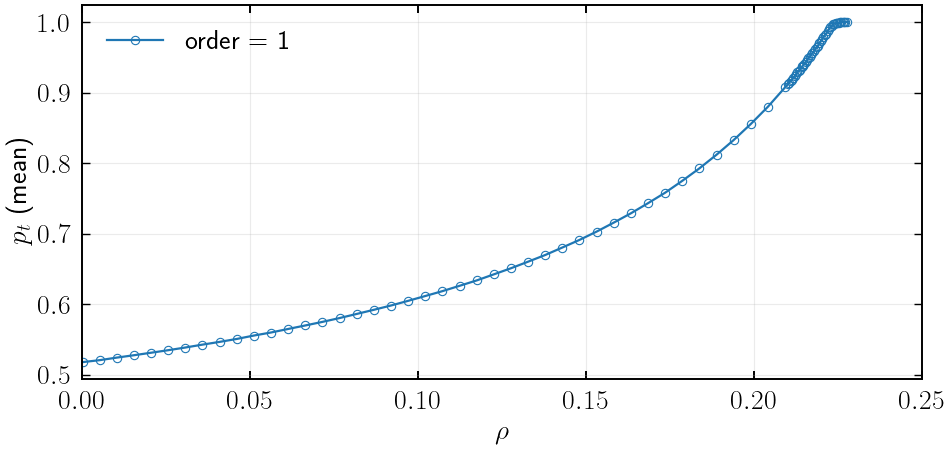

In [28]:
# === 1) manter só conjuntos com TODAS as 4 ordens ===
keys = ["type_perc","dim","num_colors","L","Nt","k","rho","p0"]  # Nt (não NT)

tmp = df_clean_3d.dropna(subset=["order"]).copy()
tmp["order"] = pd.to_numeric(tmp["order"], errors="coerce").astype("Int64")

ok = (tmp.groupby(keys)["order"]
        .nunique()
        .reset_index(name="n_orders"))

valid_keys = ok[ok["n_orders"] == 4][keys]

# dataframe apenas com conjuntos completos (ordens 1..4 presentes)
df_all4 = df_clean_3d.merge(valid_keys, on=keys, how="inner")


fig, ax = plt.subplots(figsize=(10, 5))

df_plot = df_all4[(df_all4["L"] == 512) & (df_all4["order"] == 1)].copy()
for c in ["rho", "pt_mean", "pt_erro"]:
    if c in df_plot.columns:
        df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")
df_plot = df_plot.dropna(subset=["rho", "pt_mean"]).sort_values("rho")

ax.plot(df_plot["rho"], df_plot["pt_mean"], "o-", ms=6, lw=1.6, label='order = 1')
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$p_t$ (mean)")
ax.grid(True, alpha=0.25)
ax.legend()
ax.set_xlim([0.0, 0.25])
plt.tight_layout()
plt.show()



# Pedidos

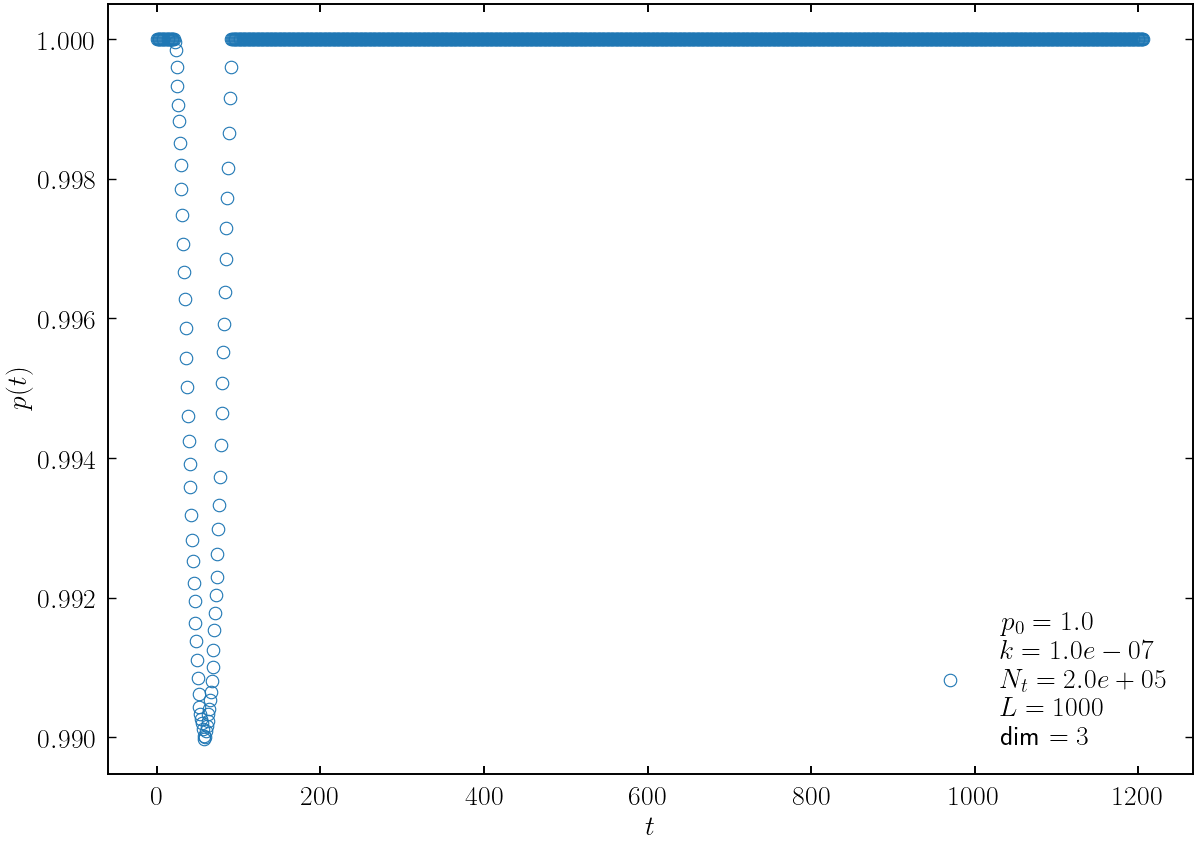

In [35]:
k = 1.0e-07
p0 = 1.0
Nt = 200000
rho = 0.001
type_perc = 'bond'
dim = 3
L = 1000
num_colors = 4
seed= 656121865
data = data_single_sample(type_perc, num_colors, dim, L, Nt, k, rho, p0, seed)
plt.plot(data['t'], data['p_1'], 'o', label=f'$p_0 = {p0}$ \n $k = {k:.1e}$ \n $N_t = {Nt:.1e}$ \n $L = {L}$\n dim $= {dim}$')
plt.xlabel("$t$")
plt.ylabel("$p(t)$")
plt.legend()
plt.show()

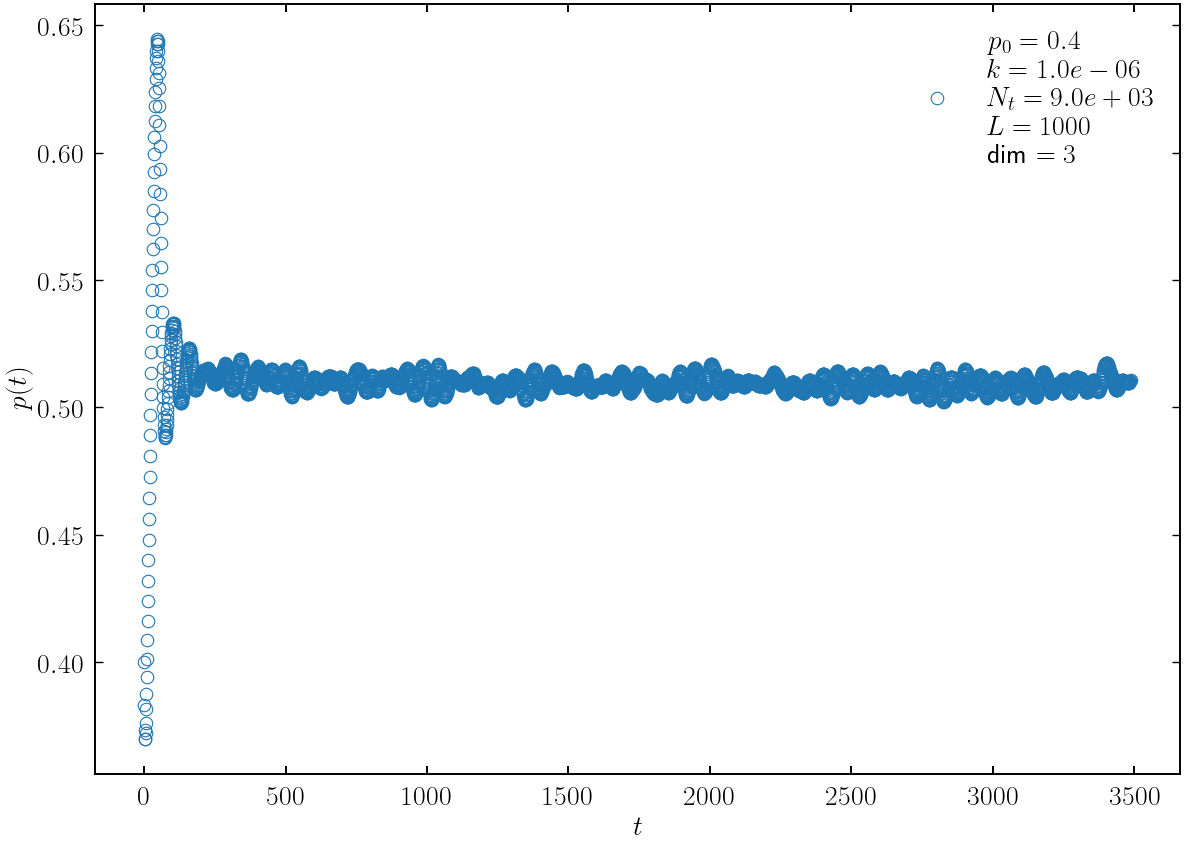

In [5]:
k = 1.0e-06
p0 = 0.4
Nt = 9000
rho = 0.001
type_perc = 'bond'
dim = 3
L = 1000
num_colors = 4
seed= 219003817
data = data_single_sample(type_perc, num_colors, dim, L, Nt, k, rho, p0, seed)
plt.plot(data['t'], data['p_1'], 'o', label=f'$p_0 = {p0}$ \n $k = {k:.1e}$ \n $N_t = {Nt:.1e}$ \n $L = {L}$\n dim $= {dim}$')
plt.xlabel("$t$")
plt.ylabel("$p(t)$")
plt.legend()
plt.show()